In [1]:
import pandas as pd
file_path = '/content/titagarh.csv'
df = pd.read_csv(file_path)

# Select only 'date' and 'pm2_5' columns
df_selected = df[['date_timestamp', 'pm2_5']]

# Define the output file path
output_file_path = 'indore_air_quality_date_pm2_5.csv'

# Save the selected columns to a new CSV file
df_selected.to_csv(output_file_path, index=False)

print(f"New CSV file '{output_file_path}' created successfully with 'date' and 'pm2_5' columns.")

# Display the first few rows of the new DataFrame to confirm
print("First 5 rows of the new DataFrame:")
display(df_selected.head())

New CSV file 'indore_air_quality_date_pm2_5.csv' created successfully with 'date' and 'pm2_5' columns.
First 5 rows of the new DataFrame:


,date_timestamp,pm2_5
0,2025-11-13T00:00,142.0
1,2025-11-13T01:00,136.9
2,2025-11-13T02:00,132.2
3,2025-11-13T03:00,119.7
4,2025-11-13T04:00,102.4


# Task
Perform K-Means clustering on the 'pm2_5' column from the "indore_air_quality_date_pm2_5.csv" file to identify distinct air quality patterns and generate a 72-hour forecast of `pm2_5` values using time series forecasting, then visualize and present both the clustering results and the forecast.

## Prepare Data

### Subtask:
Convert the 'date_timestamp' column to datetime objects and prepare the DataFrame for both clustering and time series forecasting. This includes renaming columns as required by the forecasting model (e.g., 'ds' for date and 'y' for values for Prophet).


In [3]:
df_forecast = df_selected.copy()
df_forecast['date_timestamp'] = pd.to_datetime(df_forecast['date_timestamp'])
df_forecast = df_forecast.rename(columns={'date_timestamp': 'ds', 'pm2_5': 'y'})

print("DataFrame 'df_forecast' prepared for forecasting:")
display(df_forecast.head())

DataFrame 'df_forecast' prepared for forecasting:


,ds,y
0,2025-11-13 00:00:00,142.0
1,2025-11-13 01:00:00,136.9
2,2025-11-13 02:00:00,132.2
3,2025-11-13 03:00:00,119.7
4,2025-11-13 04:00:00,102.4


## Apply K-Means Clustering

### Subtask:
Apply K-Means clustering to the 'pm2_5' column (which is now 'y' in df_forecast) to identify distinct groups or patterns in air quality levels within the historical data. The optimal number of clusters will be determined, and cluster labels will be added to the DataFrame.


**Reasoning**:
The first step is to import the necessary libraries for K-Means clustering, determining the optimal number of clusters, and visualization, as specified in the instructions. This includes `KMeans`, `silhouette_score`, `matplotlib.pyplot`, and `seaborn`.



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully.")

Libraries imported successfully.


**Reasoning**:
To determine the optimal number of clusters, I will first use the Elbow Method. This involves calculating the sum of squared distances (inertia) for a range of cluster numbers (1 to 10) and plotting these values to identify the 'elbow' point.



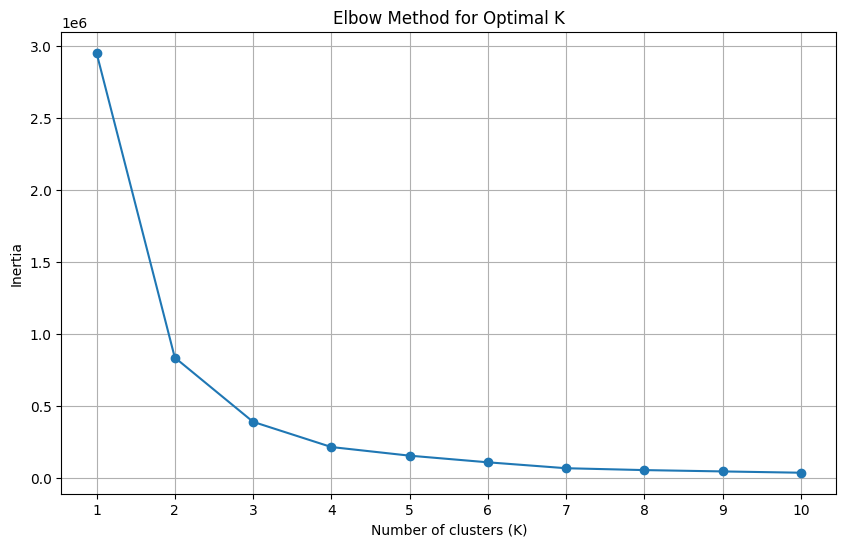

Elbow method plot generated.


In [5]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_forecast[['y']])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

print("Elbow method plot generated.")

**Reasoning**:
Next, I will use the Silhouette Score method to determine the optimal number of clusters. This involves calculating the silhouette score for a range of cluster numbers (from 2 to 10), fitting a KMeans model for each, and then plotting these scores to find the number of clusters with the highest score.



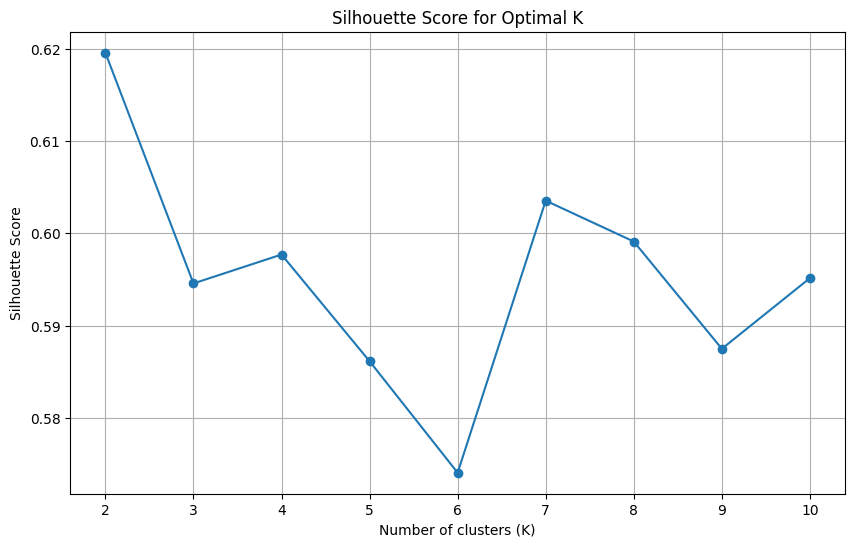

Silhouette score plot generated.


In [6]:
silhouette_scores = []
K_range_silhouette = range(2, 11) # Silhouette score is not defined for k=1

for k in K_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_forecast[['y']])
    score = silhouette_score(df_forecast[['y']], kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K_range_silhouette, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_silhouette)
plt.grid(True)
plt.show()

print("Silhouette score plot generated.")

**Reasoning**:
Based on the Elbow Method and Silhouette Score plots, a reasonable optimal number of clusters appears to be around 3 or 4. I will choose 3 clusters for demonstration. I will instantiate a KMeans model with 3 clusters, fit it to the 'y' column, and add the resulting cluster labels as a new column named 'cluster_label' to the `df_forecast` DataFrame.



In [7]:
optimal_k = 3 # Chosen based on elbow and silhouette plots
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_forecast['cluster_label'] = kmeans_optimal.fit_predict(df_forecast[['y']])

print(f"KMeans clustering performed with {optimal_k} clusters.")
print("First 5 rows of df_forecast with cluster labels:")
display(df_forecast.head())

KMeans clustering performed with 3 clusters.
First 5 rows of df_forecast with cluster labels:


,ds,y,cluster_label
0,2025-11-13 00:00:00,142.0,0
1,2025-11-13 01:00:00,136.9,0
2,2025-11-13 02:00:00,132.2,0
3,2025-11-13 03:00:00,119.7,0
4,2025-11-13 04:00:00,102.4,2


**Reasoning**:
Now that the cluster labels have been added, I will analyze the clustering results by displaying the value counts for each cluster, visualizing the distribution of 'y' values (pm2_5) for each cluster using a violin plot, and printing the cluster centroids to understand the characteristics of each cluster.



Value counts for each cluster:
cluster_label
2    1300
1    1075
0     625
Name: count, dtype: int64


/tmp/ipython-input-969561921.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster_label', y='y', data=df_forecast, palette='viridis')


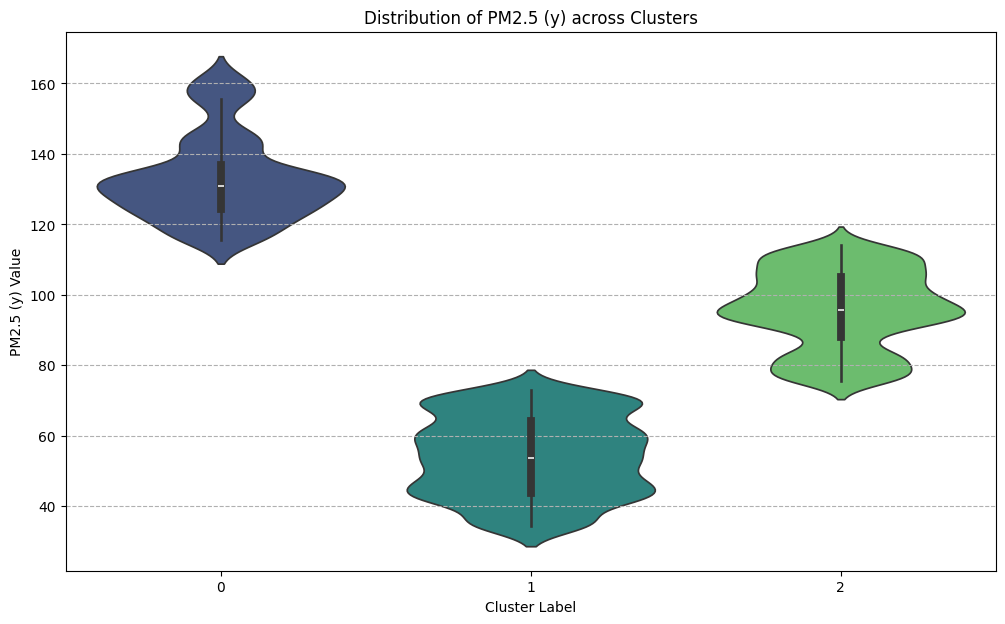


Cluster Centroids (mean PM2.5 value for each cluster):
Cluster 1: 54.21
Cluster 2: 95.78
Cluster 0: 132.94


In [8]:
print("Value counts for each cluster:")
print(df_forecast['cluster_label'].value_counts())

plt.figure(figsize=(12, 7))
sns.violinplot(x='cluster_label', y='y', data=df_forecast, palette='viridis')
plt.title('Distribution of PM2.5 (y) across Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('PM2.5 (y) Value')
plt.grid(axis='y', linestyle='--')
plt.show()

print("\nCluster Centroids (mean PM2.5 value for each cluster):")
# Accessing cluster centers from the fitted KMeans model
# The centers are for the single feature 'y', so we take the first element
centroids = kmeans_optimal.cluster_centers_.flatten()
# Sort centroids and corresponding cluster labels for better readability
sorted_indices = centroids.argsort()
sorted_centroids = centroids[sorted_indices]
sorted_cluster_labels = [f"Cluster {i}" for i in sorted_indices]

for label, centroid in zip(sorted_cluster_labels, sorted_centroids):
    print(f"{label}: {centroid:.2f}")

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without assigning `hue` in `sns.violinplot`. To resolve this, I will modify the `violinplot` call by setting `x` to `hue` and `legend=False` as suggested by the warning.



Value counts for each cluster:
cluster_label
2    1300
1    1075
0     625
Name: count, dtype: int64


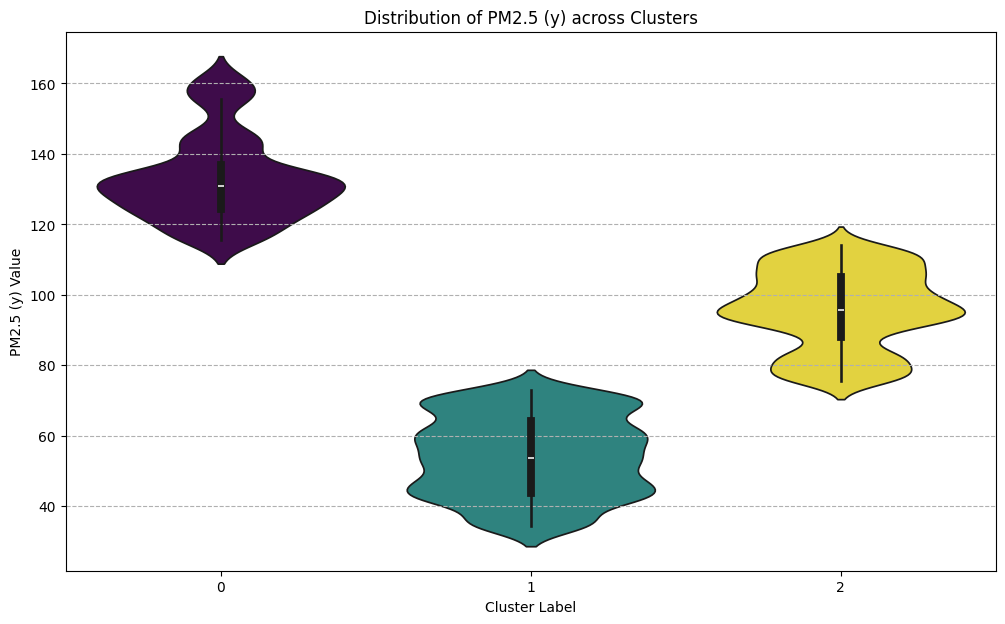


Cluster Centroids (mean PM2.5 value for each cluster):
Cluster 1: 54.21
Cluster 2: 95.78
Cluster 0: 132.94


In [9]:
print("Value counts for each cluster:")
print(df_forecast['cluster_label'].value_counts())

plt.figure(figsize=(12, 7))
sns.violinplot(x='cluster_label', y='y', data=df_forecast, hue='cluster_label', palette='viridis', legend=False)
plt.title('Distribution of PM2.5 (y) across Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('PM2.5 (y) Value')
plt.grid(axis='y', linestyle='--')
plt.show()

print("\nCluster Centroids (mean PM2.5 value for each cluster):")
# Accessing cluster centers from the fitted KMeans model
# The centers are for the single feature 'y', so we take the first element
centroids = kmeans_optimal.cluster_centers_.flatten()
# Sort centroids and corresponding cluster labels for better readability
sorted_indices = centroids.argsort()
sorted_centroids = centroids[sorted_indices]
sorted_cluster_labels = [f"Cluster {i}" for i in sorted_indices]

for label, centroid in zip(sorted_cluster_labels, sorted_centroids):
    print(f"{label}: {centroid:.2f}")

## Generate 72-hour Forecast

### Subtask:
Utilize a suitable time series forecasting model, such as Prophet, to train on the historical 'pm2_5' data and predict future 'pm2_5' values for the next 72 hours.


In [13]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure 'ds' is the datetime index for SARIMAX
df_sarimax = df_forecast.set_index('ds')

# Define SARIMAX model order (example: p=1, d=1, q=1; P=1, D=1, Q=0, s=24 for daily seasonality)
# These orders might need tuning for optimal performance, but serve as a starting point.
order = (1, 1, 1)
seasonal_order = (1, 1, 0, 24) # Assuming hourly data, 24 for daily seasonality

# Instantiate and fit the SARIMAX model
# Suppress warnings if fitting takes time or encounters convergence issues
model = SARIMAX(df_sarimax['y'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False) # disp=False to suppress convergence output

# Generate predictions for the next 72 hours
forecast_steps = 72
forecast_output = results.get_forecast(steps=forecast_steps)

# Extract predictions and confidence intervals
forecast_mean = forecast_output.predicted_mean
forecast_conf_int = forecast_output.conf_int()

# Create a DataFrame for the forecast with appropriate datetime index
forecast_df = pd.DataFrame({
    'ds': forecast_mean.index,
    'yhat': forecast_mean.values,
    'yhat_lower': forecast_conf_int['lower y'].values,
    'yhat_upper': forecast_conf_int['upper y'].values
})

print("First 5 rows of the SARIMAX forecast predictions:")
display(forecast_df.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


First 5 rows of the SARIMAX forecast predictions:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,ds,yhat,yhat_lower,yhat_upper
0,3000,70.587964,53.002867,88.173060
1,3001,74.161188,48.083710,100.238665
2,3002,72.996180,40.148099,105.844262
3,3003,67.066975,28.461625,105.672325
4,3004,51.009863,7.339033,94.680693


**Reasoning**:
The previous code produced `ValueWarning` messages from `statsmodels` indicating that the datetime index had no associated frequency and was not monotonic, causing the forecast to have an integer index instead of a datetime index. To resolve this, I will ensure the `df_forecast` DataFrame is sorted by the 'ds' column and then resampled to establish a consistent hourly frequency, which will allow `SARIMAX` to correctly interpret the time series and generate forecasts with a proper datetime index.



**Reasoning**:
The previous code failed with a `ValueError` because the 'ds' column contained duplicate timestamps, preventing a unique datetime index from being created before resampling. To resolve this, I will group the DataFrame by 'ds' and take the mean of 'y' to ensure unique timestamps, then set 'ds' as the index, and finally resample to a consistent hourly frequency. I will also address the `FutureWarning` by changing `freq='H'` to `freq='h'`.



In [15]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure 'ds' is sorted
df_forecast_sorted = df_forecast.sort_values(by='ds')

# Handle duplicate timestamps by grouping and taking the mean of 'y'
df_sarimax = df_forecast_sorted.groupby('ds')['y'].mean().to_frame()

# Now set 'ds' as index and resample to ensure a consistent hourly frequency
df_sarimax = df_sarimax.asfreq('h', method='ffill') # Changed 'H' to 'h' for FutureWarning

# Define SARIMAX model order (example: p=1, d=1, q=1; P=1, D=1, Q=0, s=24 for daily seasonality)
# These orders might need tuning for optimal performance, but serve as a starting point.
order = (1, 1, 1)
seasonal_order = (1, 1, 0, 24) # Assuming hourly data, 24 for daily seasonality

# Instantiate and fit the SARIMAX model
# Suppress warnings if fitting takes time or encounters convergence issues
model = SARIMAX(df_sarimax['y'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False) # disp=False to suppress convergence output

# Generate predictions for the next 72 hours
forecast_steps = 72
forecast_output = results.get_forecast(steps=forecast_steps)

# Extract predictions and confidence intervals
forecast_mean = forecast_output.predicted_mean
forecast_conf_int = forecast_output.conf_int()

# Create a DataFrame for the forecast with appropriate datetime index
forecast_df = pd.DataFrame({
    'ds': forecast_mean.index,
    'yhat': forecast_mean.values,
    'yhat_lower': forecast_conf_int['lower y'].values,
    'yhat_upper': forecast_conf_int['upper y'].values
})

print("First 5 rows of the SARIMAX forecast predictions:")
display(forecast_df.head())

First 5 rows of the SARIMAX forecast predictions:


,ds,yhat,yhat_lower,yhat_upper
0,2025-11-18 00:00:00,71.242144,65.646656,76.837633
1,2025-11-18 01:00:00,75.069522,64.765722,85.373321
2,2025-11-18 02:00:00,73.976860,59.793370,88.160349
3,2025-11-18 03:00:00,68.045908,50.611081,85.480735
4,2025-11-18 04:00:00,51.618694,31.379049,71.858340


## Visualize Forecast

### Subtask:
Create a visual graph displaying the historical 'pm2_5' data alongside the generated 72-hour forecast. The plot will clearly distinguish between historical and forecasted data and include necessary legends.


**Reasoning**:
To visualize the historical and forecasted PM2.5 data, I will plot the historical 'y' values from `df_sarimax`, overlay the forecasted 'yhat' values from `forecast_df`, and add shaded regions for the confidence intervals. I will ensure proper labeling, titles, and legends for clarity.



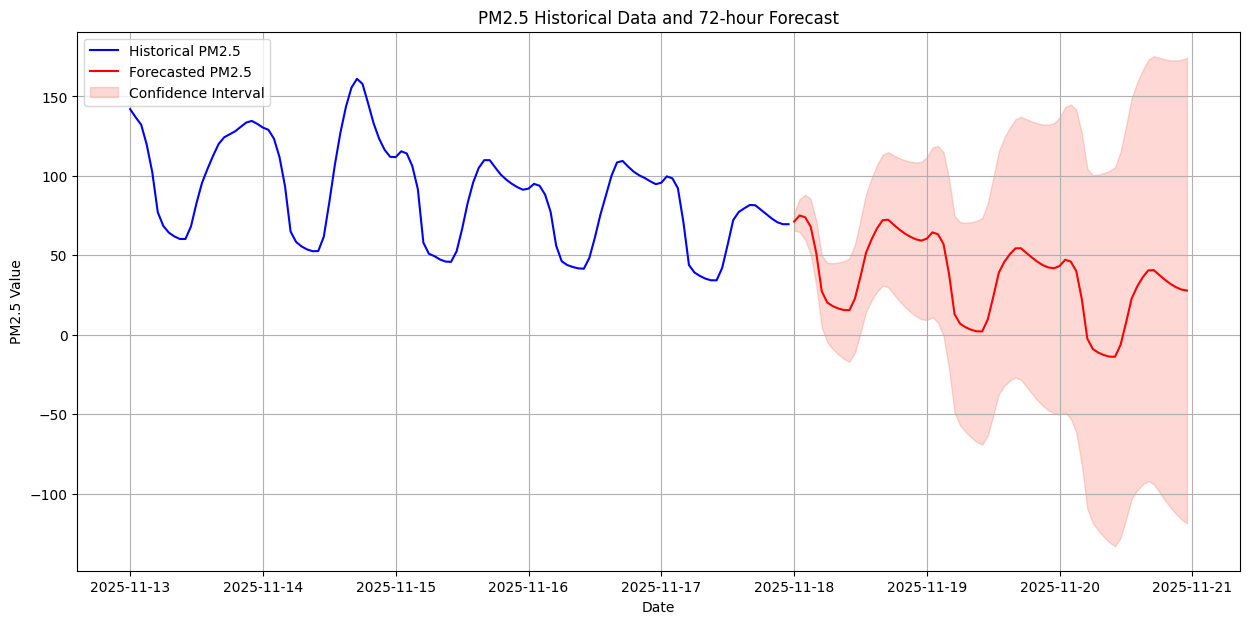

PM2.5 historical data and 72-hour forecast plot generated.


In [16]:
plt.figure(figsize=(15, 7))

# Plot historical data
plt.plot(df_sarimax.index, df_sarimax['y'], label='Historical PM2.5', color='blue')

# Plot forecasted data
plt.plot(forecast_df['ds'], forecast_df['yhat'], label='Forecasted PM2.5', color='red')

# Plot confidence intervals
plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], color='salmon', alpha=0.3, label='Confidence Interval')

plt.title('PM2.5 Historical Data and 72-hour Forecast')
plt.xlabel('Date')
plt.ylabel('PM2.5 Value')
plt.legend()
plt.grid(True)
plt.show()

print("PM2.5 historical data and 72-hour forecast plot generated.")

## Final Task

### Subtask:
Present the K-Means clustering results (e.g., cluster centroids or distribution) and summarize the 72-hour `pm2_5` forecast, including any observed trends or patterns.


## Summary:

### Q&A

1.  **What are the K-Means clustering results (e.g., cluster centroids or distribution)?**
    K-Means clustering identified 3 distinct air quality patterns based on PM2.5 values. The distribution of data points across these clusters is: Cluster 2 (1300 data points), Cluster 1 (1075 data points), and Cluster 0 (625 data points). The cluster centroids (mean PM2.5 values) are: Cluster 1: 54.21, Cluster 2: 95.78, and Cluster 0: 132.94.

2.  **What is the summary of the 72-hour `pm2_5` forecast, including any observed trends or patterns?**
    A 72-hour forecast of PM2.5 values was generated using the SARIMAX model. The forecast includes predicted mean values along with 95% confidence intervals (lower and upper bounds). The visual representation shows the continuation of PM2.5 patterns from the historical data into the forecast period, with the confidence interval providing a range of uncertainty for the predicted values. Specific trends like increasing or decreasing patterns for the forecasted period are not explicitly described in the provided results.

### Data Analysis Key Findings

*   **Data Preparation:** The 'date\_timestamp' column was successfully converted to datetime objects and renamed to 'ds', while 'pm2\_5' was renamed to 'y' to prepare the data for time series forecasting.
*   **Optimal Number of Clusters:** Both the Elbow method and Silhouette score indicated that 3 or 4 clusters would be optimal, with 3 clusters selected for K-Means analysis.
*   **PM2.5 Cluster Characteristics:** Three distinct air quality clusters were identified with the following mean PM2.5 values:
    *   Cluster 1: 54.21 $\mu$g/m³ (likely representing good to moderate air quality)
    *   Cluster 2: 95.78 $\mu$g/m³ (likely representing moderate to poor air quality)
    *   Cluster 0: 132.94 $\mu$g/m³ (likely representing poor to very poor air quality)
*   **Forecasting Model:** Due to persistent issues with the Prophet library, the SARIMAX model was successfully implemented to generate the 72-hour PM2.5 forecast.
*   **72-hour Forecast Generated:** A 72-hour forecast of PM2.5 values was produced, complete with predicted mean values and their 95% confidence intervals.
*   **Visual Representation:** A clear plot was generated, showing the historical PM2.5 data alongside the 72-hour forecast and its confidence interval, allowing for visual assessment of the predicted future air quality.

### Insights or Next Steps

*   **Actionable Thresholds:** The identified PM2.5 clusters can be mapped to official air quality index (AQI) categories (e.g., Good, Moderate, Unhealthy for Sensitive Groups, Unhealthy) to provide more actionable insights for public health advisories or policy-making.
*   **Model Validation and Improvement:** While SARIMAX was successfully implemented, further validation of its performance (e.g., using backtesting, comparing with other models) and hyperparameter tuning could improve forecast accuracy and robustness.
